In [1]:
import os
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt

from src.d_CSL import GcStar
from src.dataload import *
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = list(range(1, 4)), 1, 1000
alpha, beta = 0.001, 0

In [4]:
A = adj_mtx(30)
X_ = simulate_data(A, 40000, iid=False)

In [5]:
%%time

# load data
os.chdir(r'./data/pairs/')
names = ['pair0001.txt', 'pair0003.txt', 'pair0004.txt','pair0005.txt', 'pair0012.txt', 'pair0013.txt', 'pair0014.txt', 
         'pair0015.txt', 'pair0016.txt', 'pair0017.txt', 'pair0038.txt', 'pair0043.txt', 'pair0044.txt', 'pair0063.txt', 
         'pair0094.txt', 'pair0100.txt']
INFs = {}
for i in range(len(names)):
    data = np.loadtxt(names[i])
    l = data.shape[0]
    new = X_[:3, :l]
    X = np.r_[data.T, new]
    print(names[i])
    print('')
    
    # Analysis
    infs = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix()
        np.fill_diagonal(inf, 0)
        infs.append(inf)
    print('')
    print('')
    INFs[i] = infs

pair0001.txt

1 pasts
2 pasts
3 pasts


pair0003.txt

1 pasts
2 pasts
3 pasts


pair0004.txt

1 pasts
2 pasts
3 pasts


pair0005.txt

1 pasts
2 pasts
3 pasts


pair0012.txt

1 pasts
2 pasts
3 pasts


pair0013.txt

1 pasts
2 pasts
3 pasts


pair0014.txt

1 pasts
2 pasts
3 pasts


pair0015.txt

1 pasts
2 pasts
3 pasts


pair0016.txt

1 pasts
2 pasts
3 pasts


pair0017.txt

1 pasts
2 pasts
3 pasts


pair0038.txt

1 pasts
2 pasts
3 pasts


pair0043.txt

1 pasts
2 pasts
3 pasts


pair0044.txt

1 pasts
2 pasts
3 pasts


pair0063.txt

1 pasts
2 pasts
3 pasts


pair0094.txt

1 pasts
2 pasts
3 pasts


pair0100.txt

1 pasts
2 pasts
3 pasts


CPU times: total: 1h 44min 15s
Wall time: 27min 50s


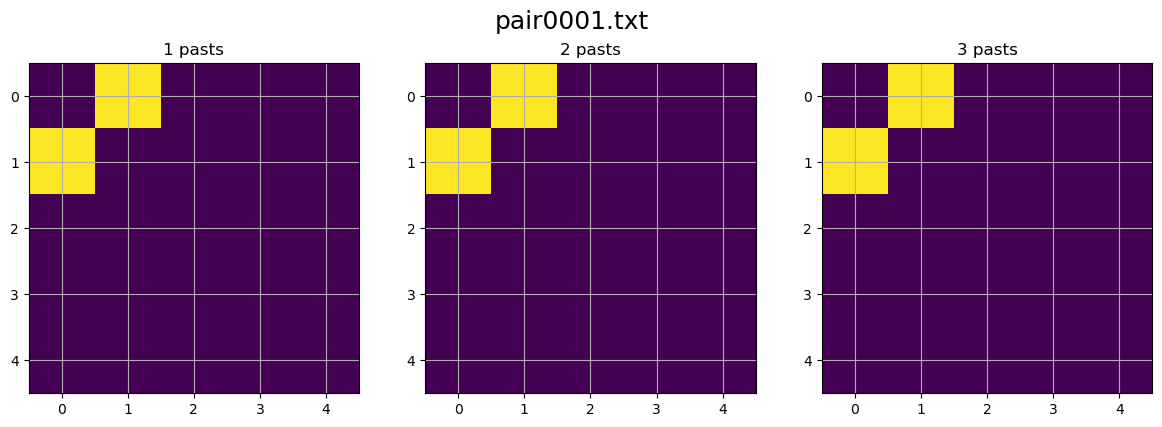

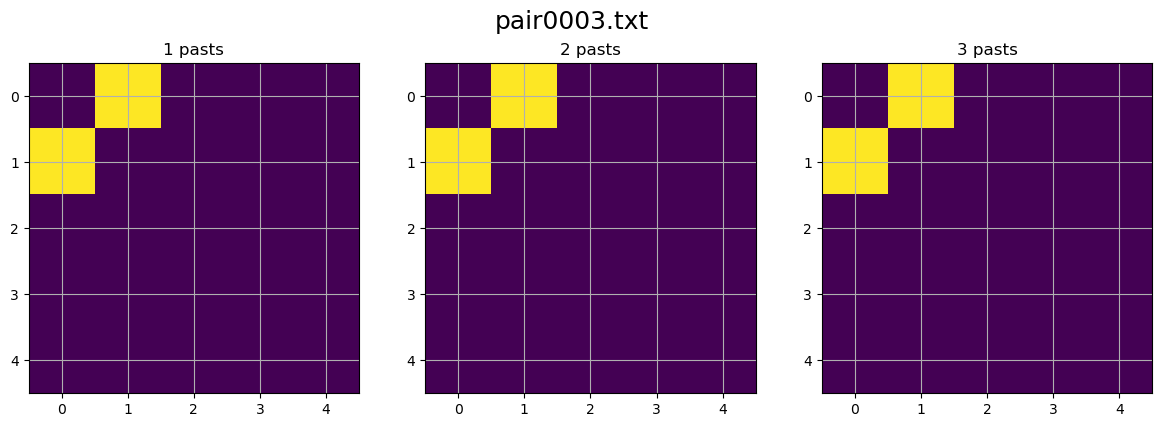

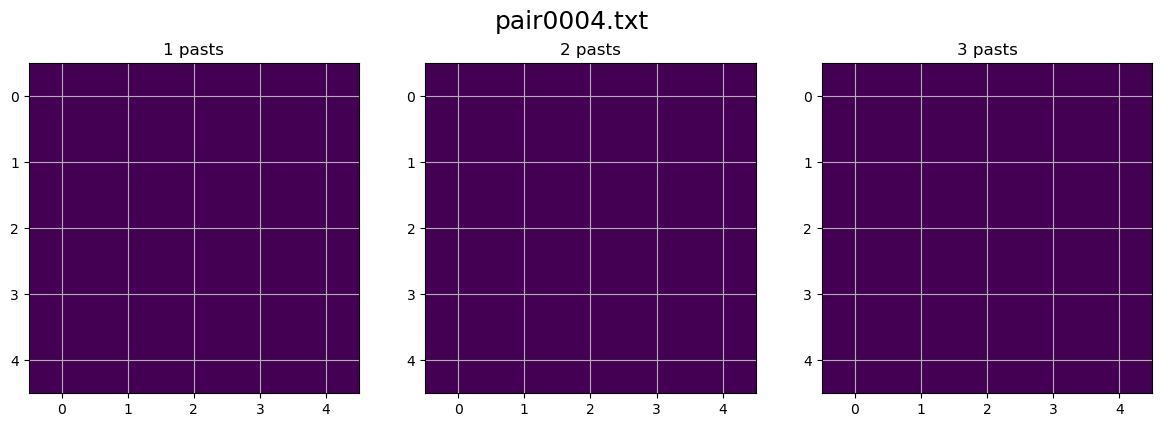

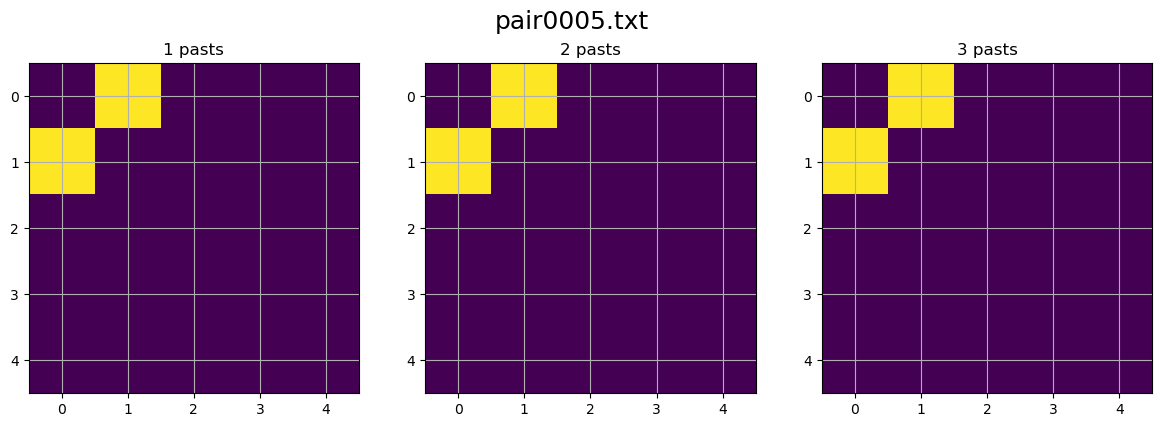

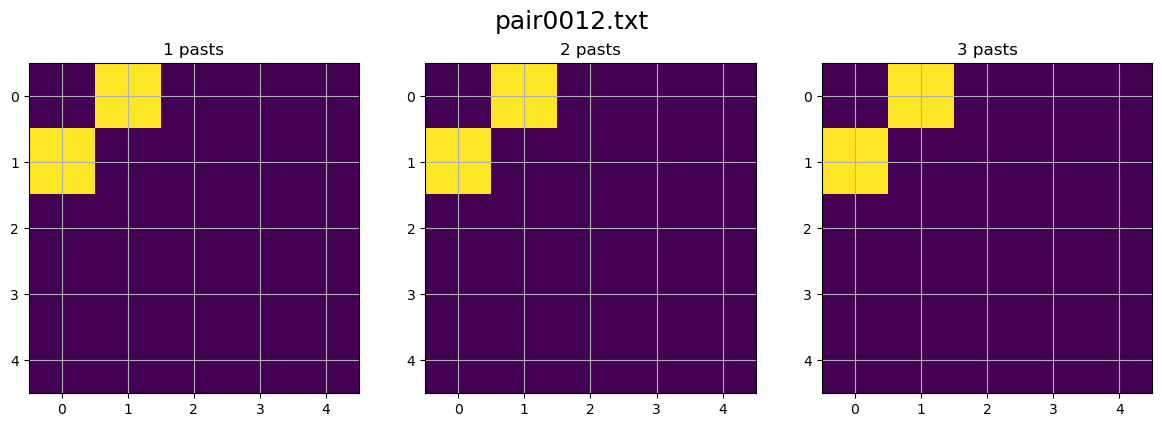

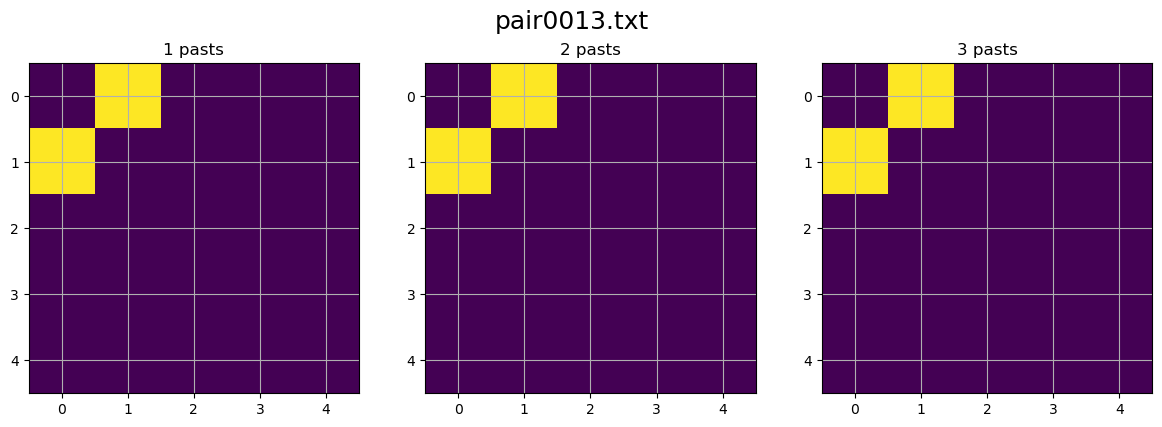

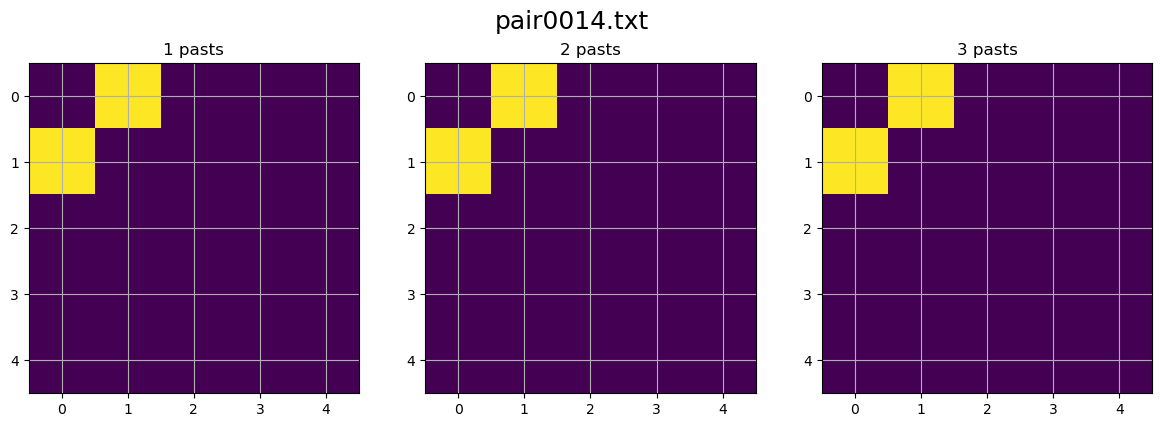

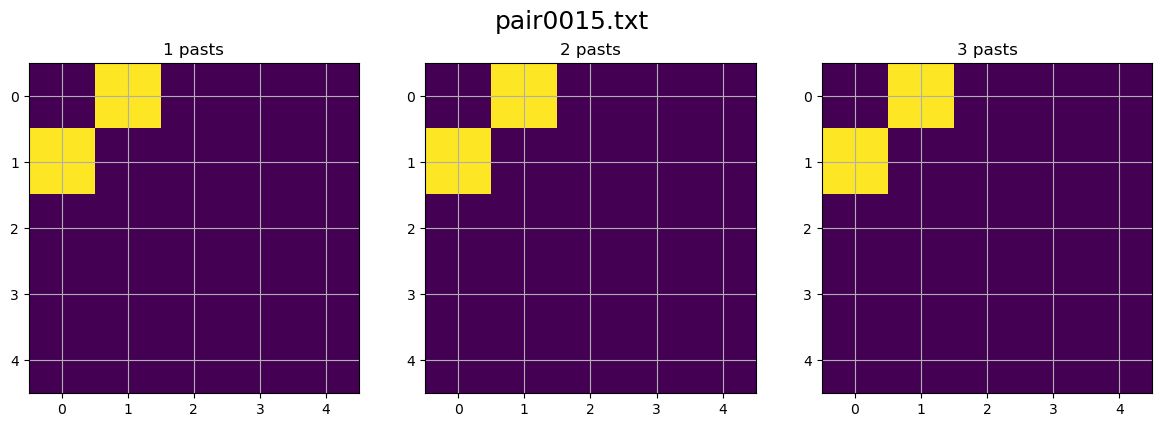

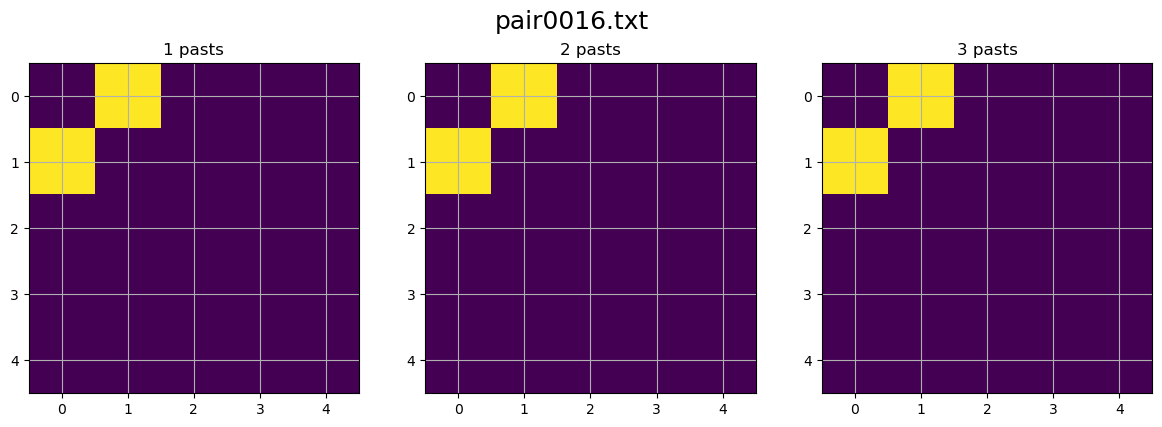

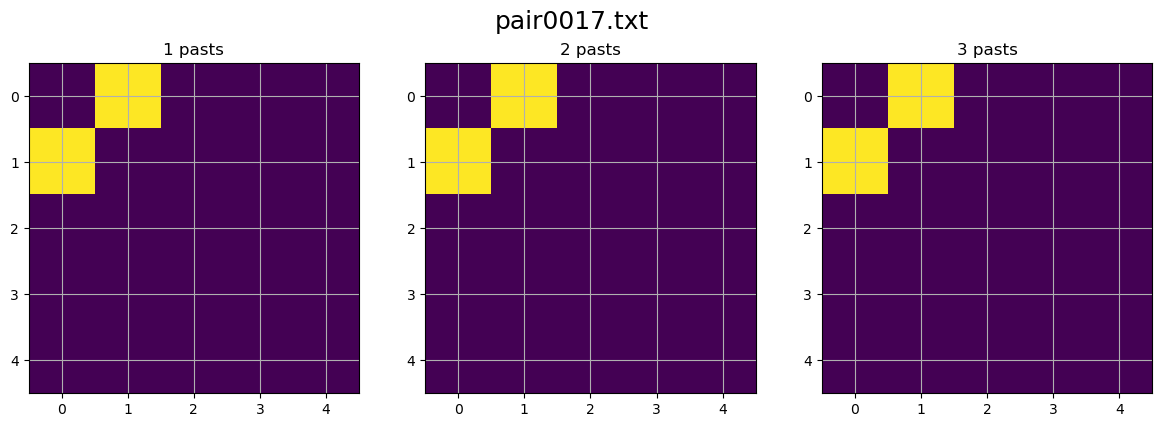

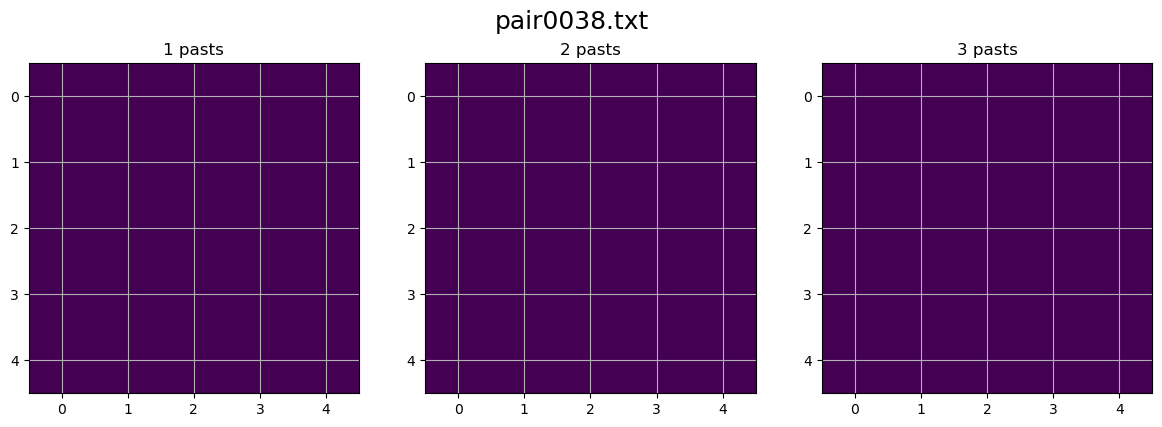

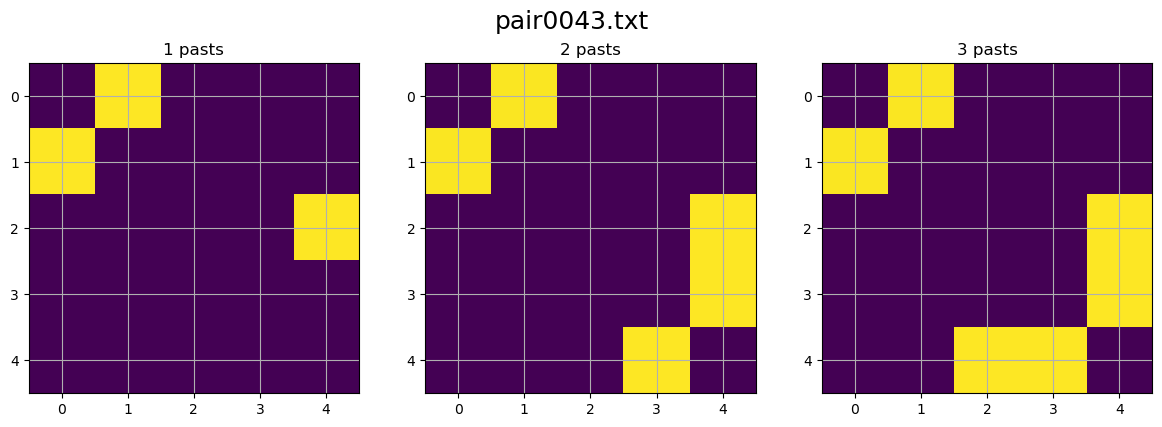

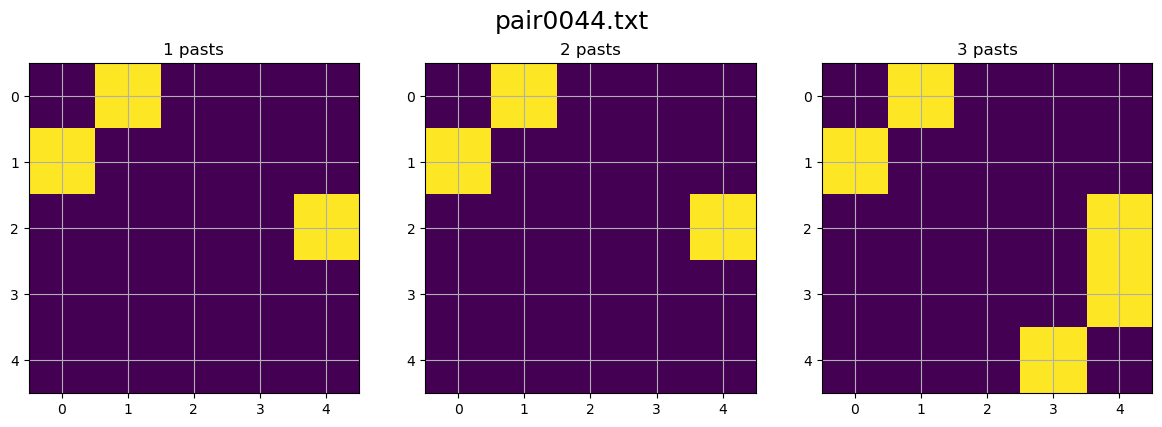

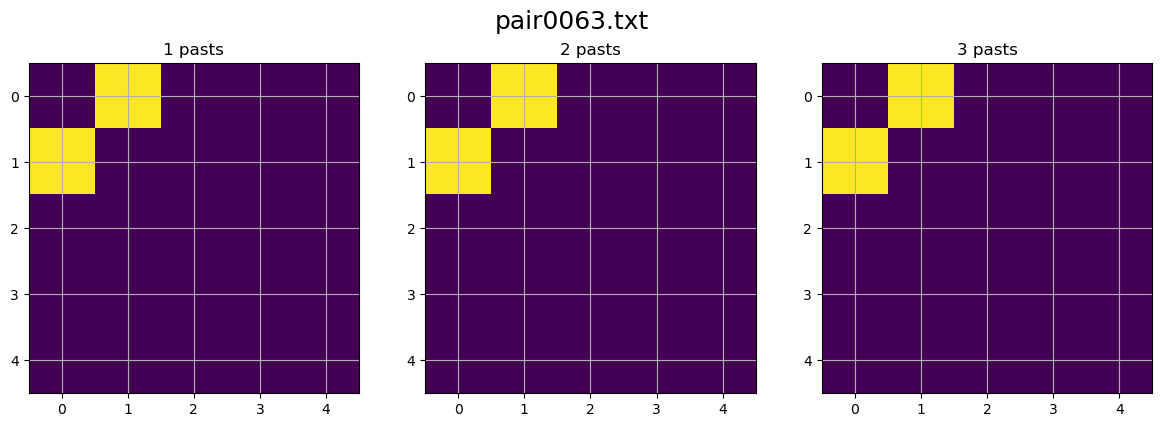

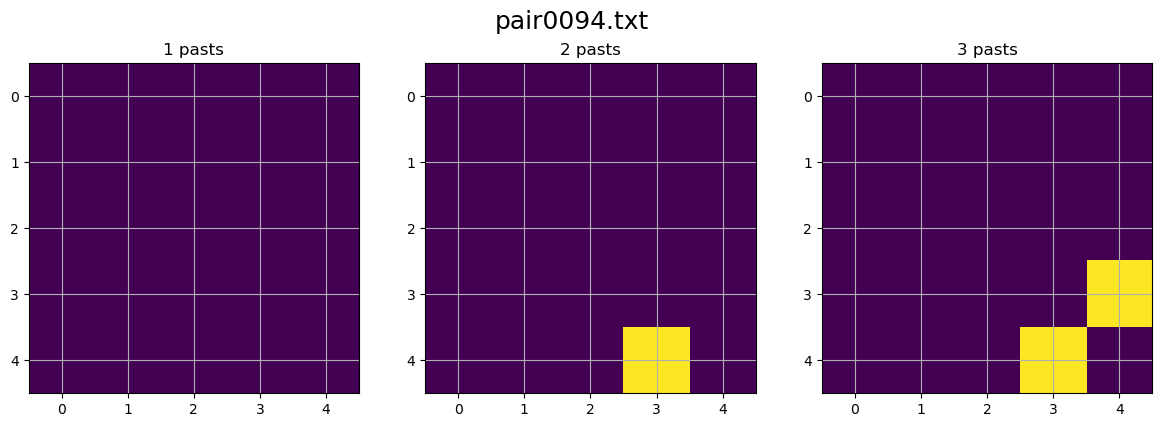

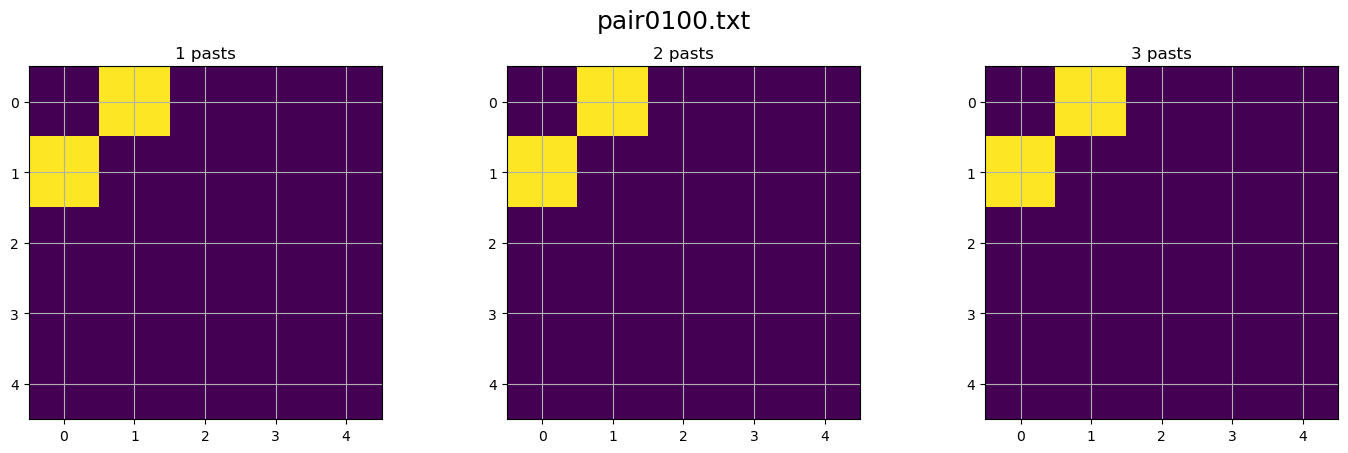

In [6]:
for i in range(len(names)):
  fig,ax = plt.subplots(1,3,figsize=(14.5,4.5))
  for j in range(3):
    ax[j].imshow(INFs[i][j])
    ax[j].set_title(f'{j+1} pasts')
    ax[j].set_xticks(np.arange(INFs[i][j].shape[0]))
    ax[j].set_yticks(np.arange(INFs[i][j].shape[0]))
    ax[j].grid()
  plt.suptitle(f'{names[i]}', fontsize=18)
plt.tight_layout()